<a href="https://colab.research.google.com/github/Asripramudiya/Sentimen/blob/main/Sentiment_Shopee.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Install Library

In [ ]:
!pip install Sastrawi
!pip install transformers torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 1.7 MB/s eta 0:00:00


# Import Library

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import string
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.stem import PorterStemmer
from nltk.stem.snowball import SnowballStemmer
from nltk.corpus import stopwords as nltk_stopwords
from nltk.tokenize import word_tokenize
from transformers import pipeline
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import joblib

nltk.download('punkt')
nltk.download('stopwords')

stopword_id = set(nltk_stopwords.words('indonesian'))
pd.set_option('display.max_colwidth', None)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# Read Data

In [ ]:
# read data
df = pd.read_csv("https://raw.githubusercontent.com/Asripramudiya/Sentimen/refs/heads/main/Shopee.csv", encoding='utf-8')
df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,c659f6d5-1256-48eb-9ffb-b5d14f4feea9,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"shopee vip tapi dibatasi brutal, jadi ga dapet benefitnya dong hadeehhh",1,0,3.77.26,2026-07-06 01:38:25,"Haii kak Rd Arga Arzula maaf ya udah buat kakak ga nyaman terkait buka Shopee langsung live. Agar aku bisa bantu cek kendalanya infoin ke aku Username, SS kendala dan detail kendala kakak boleh chat aku di DM @shopee_id ya kak. Ditunggu ^RA",2025-09-30 05:30:04,3.77.26
1,6558c37c-4c47-4b74-aed5-c72ac282c493,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,iklan nya ngeselin banget,1,0,NaN,2026-07-06 01:38:17,NaN,NaN,NaN
2,f58fe9f2-cd68-411f-b857-32a87e6e2970,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"pelayanan lebih meningkat, harus lebih banyak diskon",5,0,3.77.26,2026-07-06 01:36:20,"Hai kak, terimakasih yaa buat review dan bintang 5nya ya juga.. Semoga Shopee bisa terus kasih pelayanan yang paling mantappp buat kakak dan ngebuat pengalaman belanja online kakak semakin memuaskann! 😁 Semoga urusannya selalu dilancarkan ya kak! ^YB",2024-07-21 16:23:08,3.77.26
3,c18bfdb4-1489-4d95-b435-baf06725ffd4,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,oke,5,0,3.76.25,2026-07-06 01:34:34,"Hi kak Triwahyuni Axl, makasih ya buat bintang 5 nya, Aku tambah semangat buat kasih pelayanan yg terbaik :) Yuk pantau terus aplikasi Shopee biar nggk ketinggalan promo menarik lainnya. Klo ada pertanyaan terkait Shopee jangan sungkan DM Aku di @Shopee_id ya, sehat selalu ^KF",2026-07-06 02:33:25,3.76.25
4,a6a50f46-314c-426c-94b0-794a9c2a4a67,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,keren banget,4,0,3.77.26,2026-07-06 01:30:05,"Hai kak Aman Nulloh, makasih banyak ya buat bintang nya. Aku happy banget nih dapet bintang dari kakak. Kalo Kaka udah suka dengan Aplikasi Shopee jangan lupa naikin bintangnya jadi 5 yaa kaa. Kalo ada pertanyaan atau kendala terkait Shopee kakak bisa chat aku aja di DM IG shopee_id / shopeecare_id yaa. Bahagia selalu ^LF",2026-07-06 02:25:53,3.77.26


# Data Understanding

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              5000 non-null   object
 1   userName              5000 non-null   object
 2   userImage             5000 non-null   object
 3   content               5000 non-null   object
 4   score                 5000 non-null   int64 
 5   thumbsUpCount         5000 non-null   int64 
 6   reviewCreatedVersion  3737 non-null   object
 7   at                    5000 non-null   object
 8   replyContent          3547 non-null   object
 9   repliedAt             3547 non-null   object
 10  appVersion            3737 non-null   object
dtypes: int64(2), object(9)
memory usage: 429.8+ KB


In [ ]:
df.isnull().sum()

,0
reviewId,0
userName,0
userImage,0
content,0
score,0
thumbsUpCount,0
reviewCreatedVersion,1263
at,0
replyContent,1453
repliedAt,1453


In [ ]:
df.duplicated().sum()

np.int64(0)

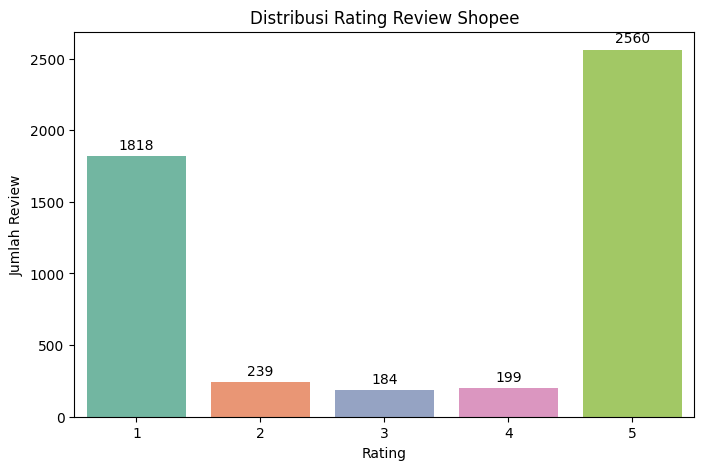

In [ ]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x='score',
    hue='score',
    palette='Set2',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.title('Distribusi Rating Review Shopee')
plt.xlabel('Rating')
plt.ylabel('Jumlah Review')

plt.show()

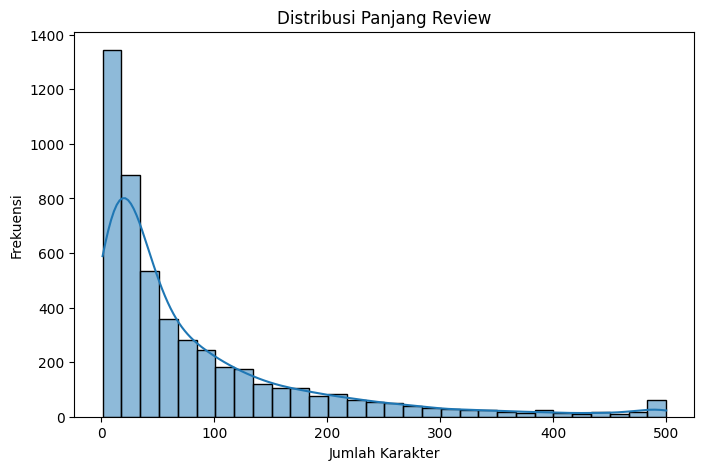

In [ ]:
df['character_count'] = df['content'].astype(str).apply(len)

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='character_count',
    bins=30,
    kde=True
)

plt.title('Distribusi Panjang Review')
plt.xlabel('Jumlah Karakter')
plt.ylabel('Frekuensi')

plt.show()

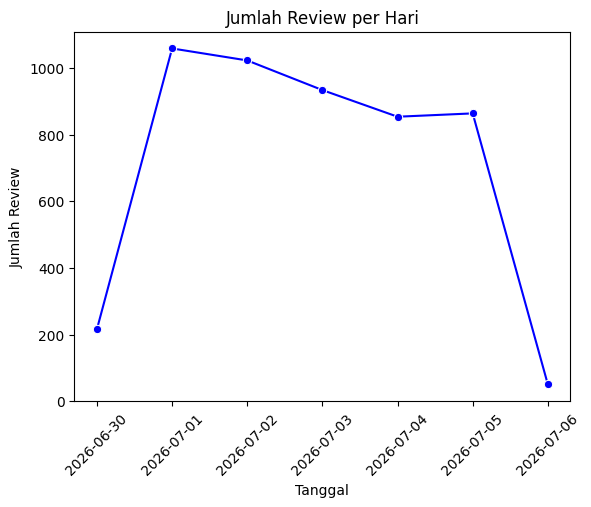

In [ ]:
# review per hari
df['at'] = pd.to_datetime(df['at'], errors='coerce')
review_daily = (
    df.groupby(df['at'].dt.date).size().reset_index(name='jumlah_review')
)

sns.lineplot(
    data=review_daily,
    x='at',
    y='jumlah_review',
    marker='o',
    color='blue'
 )

plt.title('Jumlah Review per Hari')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Review')
plt.xticks(rotation=45)

plt.show()

In [ ]:
df['appVersion'].value_counts()

,count
appVersion,
3.77.25,1651
3.76.25,713
3.77.26,661
3.75.28,143
3.74.34,61
...,...
2.98.22,1
3.26.17,1
3.63.27,1


/tmp/ipykernel_2274/4239562038.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


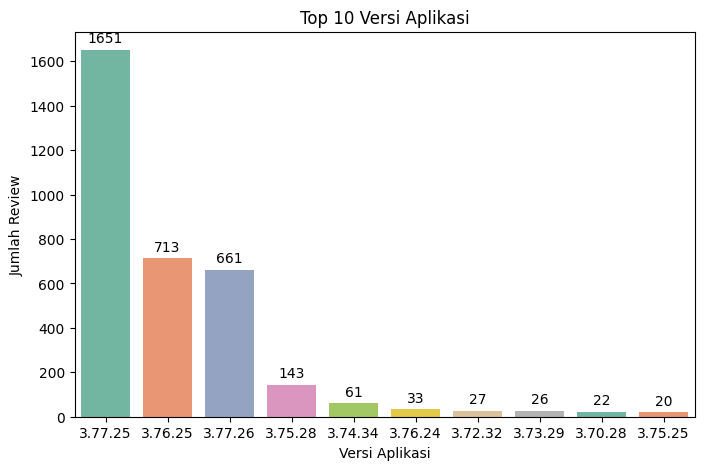

In [ ]:
top_version = df['appVersion'].value_counts().head(10)

plt.figure(figsize=(8,5))
ax = sns.barplot(
    x=top_version.index,
    y=top_version.values,
    palette='Set2'
)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.title('Top 10 Versi Aplikasi')
plt.xlabel('Versi Aplikasi')
plt.ylabel('Jumlah Review')

plt.show()

In [ ]:
# Copy dataframe
df_sentimen = df[['content']].copy()
df_sentimen.head()

,content
0,"shopee vip tapi dibatasi brutal, jadi ga dapet benefitnya dong hadeehhh"
1,iklan nya ngeselin banget
2,"pelayanan lebih meningkat, harus lebih banyak diskon"
3,oke
4,keren banget


# Data Preprocessing

## Case Folding

In [ ]:
def case_folding(content):
  if isinstance(content, str):
    lower_text = content.lower()
    return lower_text
  else:
    return content
df_sentimen['case_folding'] = df_sentimen['content'].apply(case_folding)
df_sentimen.head()

,content,case_folding
0,"shopee vip tapi dibatasi brutal, jadi ga dapet benefitnya dong hadeehhh","shopee vip tapi dibatasi brutal, jadi ga dapet benefitnya dong hadeehhh"
1,iklan nya ngeselin banget,iklan nya ngeselin banget
2,"pelayanan lebih meningkat, harus lebih banyak diskon","pelayanan lebih meningkat, harus lebih banyak diskon"
3,oke,oke
4,keren banget,keren banget


## Cleaning

In [ ]:
def cleaning(content):
    content = str(content)

    # Hapus URL
    content = re.sub(r'http\S+|www\S+|https\S+', '', content)

    # Hapus Mention
    content = re.sub(r'@\w+', '', content)

    # Hapus Hashtag
    content = re.sub(r'#\w+', '', content)

    # Hapus Emoji
    content = re.sub(
        "["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        "]+",
        '',
        content,
        flags=re.UNICODE
    )

    # Hapus tanda baca & simbol
    content = re.sub(r'[^\w\s]', ' ', content)

    # Hapus angka
    content = re.sub(r'\d+', '', content)

    # Hapus Punctuation
    content = content.translate(str.maketrans('', '', string.punctuation))

    # Hapus space berlebih
    content = re.sub(r'\s+', ' ', content).strip()

    # Hapus karakter selain huruf
    content = re.sub(r'[^a-zA-Z]', ' ', content)

    # Ganti titik menjadi spasi
    content = content.replace('.', ' ')

    # Hapus tanda baca
    content = content.translate(str.maketrans('', '', string.punctuation))

    return content

df_sentimen['cleaning'] = df_sentimen['case_folding'].apply(cleaning)
df_sentimen.head()

,content,case_folding,cleaning
0,"shopee vip tapi dibatasi brutal, jadi ga dapet benefitnya dong hadeehhh","shopee vip tapi dibatasi brutal, jadi ga dapet benefitnya dong hadeehhh",shopee vip tapi dibatasi brutal jadi ga dapet benefitnya dong hadeehhh
1,iklan nya ngeselin banget,iklan nya ngeselin banget,iklan nya ngeselin banget
2,"pelayanan lebih meningkat, harus lebih banyak diskon","pelayanan lebih meningkat, harus lebih banyak diskon",pelayanan lebih meningkat harus lebih banyak diskon
3,oke,oke,oke
4,keren banget,keren banget,keren banget


In [ ]:
df_sentimen['cleaning'].isnull().sum()

np.int64(0)

In [ ]:
df_sentimen['cleaning'].duplicated().sum()

np.int64(830)

In [ ]:
duplicate = df_sentimen[
    df_sentimen.duplicated(subset='cleaning', keep=False)
].sort_values('cleaning')

duplicate[['content', 'cleaning']].head(20)

,content,cleaning
622,👍👍,
520,👍,
4844,♥️,
790,😍😍😍,
4764,👍,
4920,👍,
3654,👍,
1206,⭐⭐⭐⭐⭐⭐,
809,1🔥,
4386,😘😘,


In [ ]:
# hapus data duplicat
df_sentimen = (df_sentimen.drop_duplicates(subset='cleaning').reset_index(drop=True))

In [ ]:
df_sentimen.duplicated().sum()

np.int64(0)

## Normalisasi Slang

In [ ]:
slang_dict = {

    "gk":"tidak",
    "ga":"tidak",
    "gak":"tidak",
    "ngga":"tidak",
    "nggak":"tidak",
    "kga":"tidak",
    "kagak":"tidak",
    "tdk":"tidak",
    "tak":"tidak",

    "yg":"yang",
    "dg":"dengan",
    "dgn":"dengan",
    "dr":"dari",
    "drpd":"daripada",
    "utk":"untuk",
    "krn":"karena",
    "karna":"karena",
    "pd":"pada",
    "dlm":"dalam",
    "jd":"jadi",
    "jdi":"jadi",
    "trs":"terus",
    "trus":"terus",
    "tp":"tapi",
    "tpi":"tapi",
    "ato":"atau",
    "atoh":"atau",
    "klu":"kalau",
    "klo":"kalau",
    "kl":"kalau",

    "udh":"sudah",
    "udah":"sudah",
    "uda":"sudah",
    "sdh":"sudah",
    "blm":"belum",
    "blom":"belum",
    "blum":"belum",
    "msh":"masih",
    "masi":"masih",
    "skrng":"sekarang",
    "skrg":"sekarang",
    "kmrn":"kemarin",
    "bsk":"besok",

    "aja":"saja",
    "aj":"saja",
    "doang":"saja",
    "sm":"sama",
    "ama":"sama",
    "sy":"saya",
    "gw":"saya",
    "gua":"saya",
    "gue":"saya",
    "aq":"saya",
    "akuh":"saya",
    "km":"kamu",
    "loe":"kamu",
    "lu":"kamu",
    "bro":"saudara",
    "sis":"saudari",

    "bgt":"banget",
    "bngt":"banget",
    "bgtt":"banget",
    "bgttt":"banget",
    "bnget":"banget",
    "parahhh":"parah",
    "parahh":"parah",
    "bangett":"banget",
    "bangettt":"banget",

    "mantul":"mantap",
    "mantapp":"mantap",
    "mantappp":"mantap",
    "mantaaaap":"mantap",
    "jos":"bagus",
    "sip":"bagus",
    "kereeen":"keren",
    "kerennn":"keren",
    "bagusss":"bagus",
    "bagussss":"bagus",
    "ok":"oke",
    "okee":"oke",
    "okey":"oke",
    "good":"bagus",
    "best":"terbaik",
    "top":"bagus",

    "lemot":"lambat",
    "ngelag":"lambat",
    "lag":"lambat",
    "loading":"muat",
    "eror":"error",
    "erorr":"error",
    "errorrr":"error",
    "ngeload":"muat",
    "forceclose":"force close",
    "fc":"force close",
    "crash":"force close",
    "hang":"macet",
    "ngehang":"macet",
    "bugg":"bug",
    "buggy":"bug",

    "kecewaa":"kecewa",
    "kecewaa":"kecewa",
    "kesell":"kesal",
    "keselll":"kesal",
    "puass":"puas",
    "puasss":"puas",
    "seneng":"senang",
    "senengg":"senang",
    "sukaa":"suka",
    "sukaaa":"suka",

    "apk":"aplikasi",
    "app":"aplikasi",
    "apps":"aplikasi",
    "loginnya":"login",
    "loginnya":"login",
    "checkoutnya":"checkout",
    "checkot":"checkout",
    "ckout":"checkout",
    "co":"checkout",
    "paylater":"pay later",
    "spaylater":"shopee pay later",
    "shopepay":"shopee pay",
    "spay":"shopee pay",
    "codnya":"cod",
    "ongkirnya":"ongkir",
    "voucheran":"voucher",
    "vouchernya":"voucher",
    "diskonnya":"diskon",
    "cashbacknya":"cashback",
    "refundnya":"refund",

    "pengirimannya":"pengiriman",
    "pengirimn":"pengiriman",
    "ngirim":"kirim",
    "dikirimnya":"kirim",
    "sampe":"sampai",
    "ampe":"sampai",
    "nyampe":"sampai",
    "nyampenya":"sampai",
    "cepet":"cepat",
    "cepett":"cepat",
    "cepettt":"cepat",
    "lamaaa":"lama",
    "lamaaaa":"lama",
    "lambatt":"lambat",
    "lambattt":"lambat",

    "barangnya":"barang",
    "barangnyaa":"barang",
    "produknya":"produk",
    "sellernya":"seller",
    "tokonya":"toko",
    "packingnya":"packing",
    "packaging":"kemasan",
    "kemasannya":"kemasan",

    "murahhh":"murah",
    "murahh":"murah",
    "mahall":"mahal",
    "mahalhh":"mahal",

    "rekomen":"rekomendasi",
    "recommended":"rekomendasi",
    "recomended":"rekomendasi",
    "recomend":"rekomendasi",
    "worthit":"layak",
    "worth":"layak",

    "bner":"benar",
    "bnr":"benar",
    "dapet":"dapat",
    "dpet":"dapat",
    "gmn":"bagaimana",
    "gmna":"bagaimana",
    "knp":"kenapa",
    "kenap":"kenapa",
    "org":"orang",
    "pngn":"ingin",
    "pgn":"ingin",
    "udhla":"sudahlah",
    "smoga":"semoga",
    "moga":"semoga",
    "donlod" : "download",
    "hadeehhh" : "haduh",
    "benefitnya" : "benefit",
    "bgus" : "bagus",
    "bagu" : "bagus",
    "kalo" : "kalau",
    "utk" : "untuk",

    "ad" : "ada",
    "ahir" : "akhir",
    "ai" : "aku",
    "aing" : "aku",
    "aju" : "aku",
    "aju" : "aku",
    "akuu" : "aku",
    "burik" : "buruk",
    "boborok" : "buruk",
    "busuk" : "buruk",
    "appnya" : "aplikasi",
    "apus" : "hapus",
    "asa" : "asal",
    "atw" : "atau",
    "bad" : "buruk",
    "asw" : "buruk",
    "moga" : "semoga",
    "anjg" : "buruk",
    "banget" : "sangat",
    "apl" : "aplikasi",
    "bbrp" : "beberapa",
    "bbrpa" : "beberapa",

    "alam" : "akan",
    "alas" : "alat",
    "rb" : "ribu",
    "tgl" : "tanggal",
    "gj" : "tidak jelas",
    "gajelas" : "tidak jelas",
    "shope" : "shopee",
    "shoope" : "shopee",
    "shopi" : "shopee",
    "shopie" : "shopee",
    "tbtb" : "tiba-tiba",
    "bal" : "balas",
    "bales" : "balas",
    "balikin" : "mengembalikan",
    "lgi" : "lagi",
    "passkw" : "tiruan",
    "beast" : "bagus",
    "bener" : "benar",
    "bgs" : "bagus",
    "bget" : "banget",
    "bgst" : "buruk",
    "bgtu" : "begitu",
    "barang" : "barang",
    "bnyk" : "banyak",
    "bru" : "baru",
    "bs" : "bisa",
    "bsa" : "bisa",
    "kuy" : "ayo",
    "tidal" : "tidak",
    "no" : "nomor",
    "shopinya" : "shopee",
    "dowlod" : "download",
    "lg" : "lagi",
    "hrus" : "harus",
    "make" : "memakai",
    "tlpn" : "telepon",
    "bntuanny" : "bantuan",
    "murmer" : "murah",
    "gercep" : "cepat",
    "lbh" : "lebih",
    "biar" : "agar",
    "tau" : "tahu"

}

def normalize_slang(cleaning):
    words = str(cleaning).split()
    normalized_words = []

    for word in words:
      if word in slang_dict:
        normalized_words.append(slang_dict[word])
      else:
        normalized_words.append(word)

    return ' '.join(normalized_words)

df_sentimen['normalize'] = df_sentimen['cleaning'].apply(normalize_slang)
df_sentimen.head()

,content,case_folding,cleaning,normalize
0,"shopee vip tapi dibatasi brutal, jadi ga dapet benefitnya dong hadeehhh","shopee vip tapi dibatasi brutal, jadi ga dapet benefitnya dong hadeehhh",shopee vip tapi dibatasi brutal jadi ga dapet benefitnya dong hadeehhh,shopee vip tapi dibatasi brutal jadi tidak dapat benefit dong haduh
1,iklan nya ngeselin banget,iklan nya ngeselin banget,iklan nya ngeselin banget,iklan nya ngeselin sangat
2,"pelayanan lebih meningkat, harus lebih banyak diskon","pelayanan lebih meningkat, harus lebih banyak diskon",pelayanan lebih meningkat harus lebih banyak diskon,pelayanan lebih meningkat harus lebih banyak diskon
3,oke,oke,oke,oke
4,keren banget,keren banget,keren banget,keren sangat


## Sentimen Labeling (IndoBERT)

In [ ]:
classifier = pipeline("sentiment-analysis", model="mdhugol/indonesia-bert-sentiment-classification")

config.json:   0%|          | 0.00/1.17k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
df_sentimen['normalize'].head()

,normalize
0,shopee vip tapi dibatasi brutal jadi tidak dapat benefit dong haduh
1,iklan nya ngeselin sangat
2,pelayanan lebih meningkat harus lebih banyak diskon
3,oke
4,keren sangat


In [ ]:
# Lakukan prediksi sentimen
hasil = classifier(df_sentimen['normalize'].tolist(), batch_size=16, truncation=True, max_length=512)

# Simpan label
df_sentimen['label'] = [x['label'] for x in hasil]
label_map = {"LABEL_0": "positif", "LABEL_1": "netral", "LABEL_2": "negatif"}
df_sentimen['label'] = df_sentimen['label'].map(label_map)
df_sentimen.head()

,content,case_folding,cleaning,normalize,label
0,"shopee vip tapi dibatasi brutal, jadi ga dapet benefitnya dong hadeehhh","shopee vip tapi dibatasi brutal, jadi ga dapet benefitnya dong hadeehhh",shopee vip tapi dibatasi brutal jadi ga dapet benefitnya dong hadeehhh,shopee vip tapi dibatasi brutal jadi tidak dapat benefit dong haduh,negatif
1,iklan nya ngeselin banget,iklan nya ngeselin banget,iklan nya ngeselin banget,iklan nya ngeselin sangat,negatif
2,"pelayanan lebih meningkat, harus lebih banyak diskon","pelayanan lebih meningkat, harus lebih banyak diskon",pelayanan lebih meningkat harus lebih banyak diskon,pelayanan lebih meningkat harus lebih banyak diskon,negatif
3,oke,oke,oke,oke,positif
4,keren banget,keren banget,keren banget,keren sangat,positif


In [ ]:
# cek jenis sentimen
df_sentimen['label'].value_counts()

,count
label,
negatif,2215
positif,1667
netral,288


## Tokenization

In [ ]:
def tokenization(normalize):
    tokens = normalize.split()
    return tokens
df_sentimen['tokenize'] = df_sentimen['normalize'].apply(tokenization)
df_sentimen.head()

,content,case_folding,cleaning,normalize,label,tokenize
0,"shopee vip tapi dibatasi brutal, jadi ga dapet benefitnya dong hadeehhh","shopee vip tapi dibatasi brutal, jadi ga dapet benefitnya dong hadeehhh",shopee vip tapi dibatasi brutal jadi ga dapet benefitnya dong hadeehhh,shopee vip tapi dibatasi brutal jadi tidak dapat benefit dong haduh,negatif,"[shopee, vip, tapi, dibatasi, brutal, jadi, tidak, dapat, benefit, dong, haduh]"
1,iklan nya ngeselin banget,iklan nya ngeselin banget,iklan nya ngeselin banget,iklan nya ngeselin sangat,negatif,"[iklan, nya, ngeselin, sangat]"
2,"pelayanan lebih meningkat, harus lebih banyak diskon","pelayanan lebih meningkat, harus lebih banyak diskon",pelayanan lebih meningkat harus lebih banyak diskon,pelayanan lebih meningkat harus lebih banyak diskon,negatif,"[pelayanan, lebih, meningkat, harus, lebih, banyak, diskon]"
3,oke,oke,oke,oke,positif,[oke]
4,keren banget,keren banget,keren banget,keren sangat,positif,"[keren, sangat]"


## Stopword Removal

In [ ]:
custom_stopwords = {
    'nya',
    'aja',
    'dong',
    'nih',
    'deh',
    'kok',
    'lah',
    'pun',
    'ya',
    'yah',
    'kan',
    'hehe',
    'wkwk',
    'wk',
    'haha',
    'hahaha',
    'dll',
    'dsb',
    'etc',
    'haduh',
    'waduh',
    'aduh',
    'jis',
    'job',
    'sen',
    'dah',
    'kek',
    'si',
    'mah',
    'ah',
    'an',
    'mu',
    'sih',
    'ter',
    'the',
    'pas',
    'up',
    'ku',
    'ni',
    'no'
}

stopword_id.update(custom_stopwords)

def remove_stopwords(tokenize):
  return [word for word in tokenize if word not in stopword_id]
df_sentimen['stopword'] = df_sentimen['tokenize'].apply(remove_stopwords)
df_sentimen.head()

,content,case_folding,cleaning,normalize,label,tokenize,stopword
0,"shopee vip tapi dibatasi brutal, jadi ga dapet benefitnya dong hadeehhh","shopee vip tapi dibatasi brutal, jadi ga dapet benefitnya dong hadeehhh",shopee vip tapi dibatasi brutal jadi ga dapet benefitnya dong hadeehhh,shopee vip tapi dibatasi brutal jadi tidak dapat benefit dong haduh,negatif,"[shopee, vip, tapi, dibatasi, brutal, jadi, tidak, dapat, benefit, dong, haduh]","[shopee, vip, dibatasi, brutal, benefit]"
1,iklan nya ngeselin banget,iklan nya ngeselin banget,iklan nya ngeselin banget,iklan nya ngeselin sangat,negatif,"[iklan, nya, ngeselin, sangat]","[iklan, ngeselin]"
2,"pelayanan lebih meningkat, harus lebih banyak diskon","pelayanan lebih meningkat, harus lebih banyak diskon",pelayanan lebih meningkat harus lebih banyak diskon,pelayanan lebih meningkat harus lebih banyak diskon,negatif,"[pelayanan, lebih, meningkat, harus, lebih, banyak, diskon]","[pelayanan, meningkat, diskon]"
3,oke,oke,oke,oke,positif,[oke],[oke]
4,keren banget,keren banget,keren banget,keren sangat,positif,"[keren, sangat]",[keren]


# Stemming Bahasa Indonesia

In [ ]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stemming(tokens):
  kalimat = ' '.join(tokens)
  return stemmer.stem(kalimat)

df_sentimen['stemming'] = df_sentimen['stopword'].apply(stemming)
df_sentimen.head()

,content,case_folding,cleaning,normalize,label,tokenize,stopword,stemming
0,"shopee vip tapi dibatasi brutal, jadi ga dapet benefitnya dong hadeehhh","shopee vip tapi dibatasi brutal, jadi ga dapet benefitnya dong hadeehhh",shopee vip tapi dibatasi brutal jadi ga dapet benefitnya dong hadeehhh,shopee vip tapi dibatasi brutal jadi tidak dapat benefit dong haduh,negatif,"[shopee, vip, tapi, dibatasi, brutal, jadi, tidak, dapat, benefit, dong, haduh]","[shopee, vip, dibatasi, brutal, benefit]",shopee vip batas brutal benefit
1,iklan nya ngeselin banget,iklan nya ngeselin banget,iklan nya ngeselin banget,iklan nya ngeselin sangat,negatif,"[iklan, nya, ngeselin, sangat]","[iklan, ngeselin]",iklan ngeselin
2,"pelayanan lebih meningkat, harus lebih banyak diskon","pelayanan lebih meningkat, harus lebih banyak diskon",pelayanan lebih meningkat harus lebih banyak diskon,pelayanan lebih meningkat harus lebih banyak diskon,negatif,"[pelayanan, lebih, meningkat, harus, lebih, banyak, diskon]","[pelayanan, meningkat, diskon]",layan tingkat diskon
3,oke,oke,oke,oke,positif,[oke],[oke],oke
4,keren banget,keren banget,keren banget,keren sangat,positif,"[keren, sangat]",[keren],keren


In [ ]:
# cek hasil stopword yang kosong
(df_sentimen['stopword'].apply(len) == 0).sum()

np.int64(22)

In [ ]:
# hapus review yang kosong setelah stopword
df_sentimen = df_sentimen[df_sentimen['stopword'].apply(len) > 0].reset_index(drop=True)

In [ ]:
# cek hasil stemming tang kosong
(df_sentimen['stemming'].str.strip() == "").sum()

np.int64(0)

In [ ]:
# cek duplicate setelah stemming
df_sentimen.duplicated(subset='stemming').sum()

np.int64(322)

In [ ]:
# lihat data yang duplikat
duplicate = df_sentimen[
    df_sentimen.duplicated(subset='stemming', keep=False)
].sort_values('stemming')

duplicate[['content', 'stemming', 'label']].head(20)

,content,stemming,label
1817,selalu amanah,amanah,positif
1001,amanah,amanah,positif
2447,baik apl nya kok ...,aplikasi,positif
581,APLIKASI BAIK,aplikasi,positif
1506,aplikasi yg sangat bagus,aplikasi bagus,positif
828,aplikasi bagusss,aplikasi bagus,positif
1994,aplikasi ini sangat bagus,aplikasi bagus,positif
3937,aplikasi bagus,aplikasi bagus,positif
3374,aplikasi yang sangat bagus,aplikasi bagus,positif
933,aplikasi sangat bagus,aplikasi bagus,positif


In [ ]:
label_check = (
    df_sentimen.groupby('stemming')['label']
    .nunique()
    .reset_index(name='jumlah_label')
)

label_check.sort_values('jumlah_label', ascending=False).head(20)

,stemming,jumlah_label
1327,iklan,3
2030,kirim,2
2641,oke,2
1103,diskon,2
2978,rekomended,2
463,bagus,2
3765,update,2
2789,pesan,2
2037,kirim cepat,2
3584,tingkat layan,2


# EDA

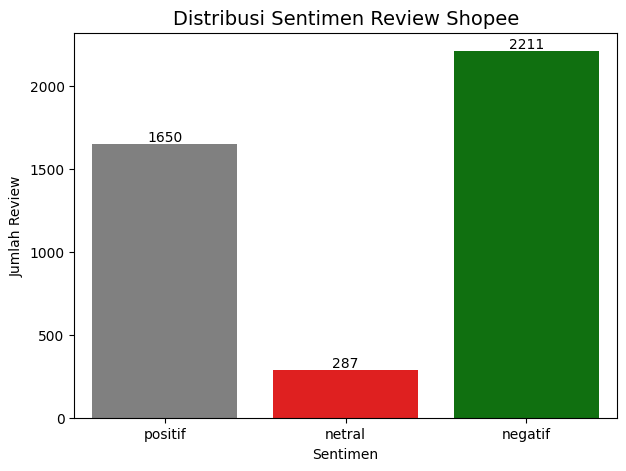

In [ ]:
# distribusi sentimen
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df_sentimen,
    x='label',
    order=['positif','netral','negatif'],
    hue='label',
    palette=['green','gray','red'],
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title('Distribusi Sentimen Review Shopee', fontsize=14)
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Review')

plt.show()

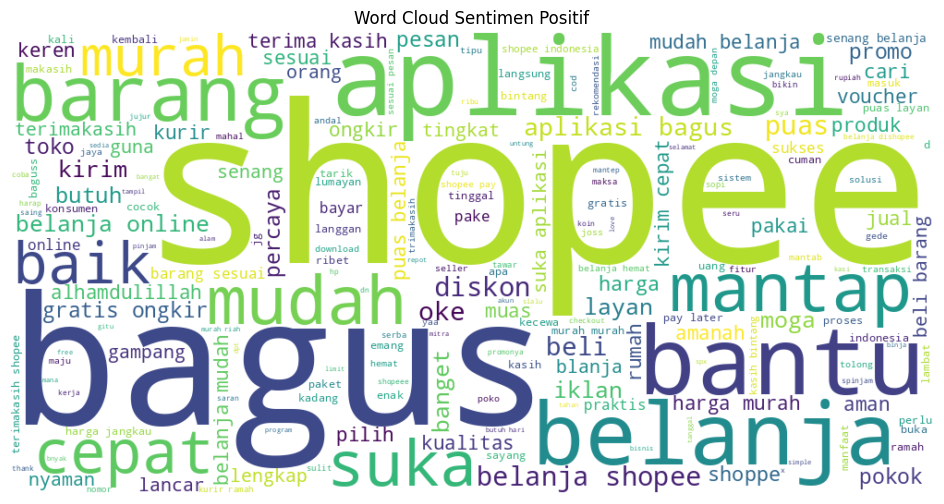

In [ ]:
# wordcloud positif
positif_text = " ".join(df_sentimen[df_sentimen['label']=='positif']['stemming'])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(positif_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud Sentimen Positif")
plt.show()

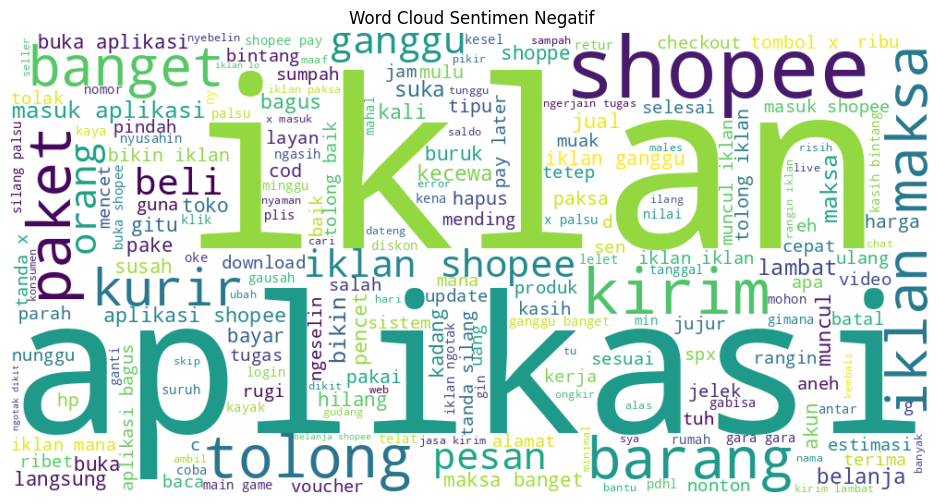

In [ ]:
# wordcloud negatif
negatif_text = " ".join(df_sentimen[df_sentimen['label']=='negatif']['stemming'])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(negatif_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud Sentimen Negatif")
plt.show()

In [ ]:
# top frequent words
from collections import Counter

all_words = " ".join(df_sentimen['stemming']).split()

counter = Counter(all_words)

top_words = counter.most_common(20)

In [ ]:
top_words_df = pd.DataFrame(
    top_words,
    columns=['Kata','Frekuensi']
)

top_words_df.head(20)

,Kata,Frekuensi
0,iklan,1795
1,shopee,1506
2,aplikasi,1383
3,belanja,574
4,bagus,531
5,barang,481
6,maksa,438
7,kirim,434
8,tolong,367
9,banget,365


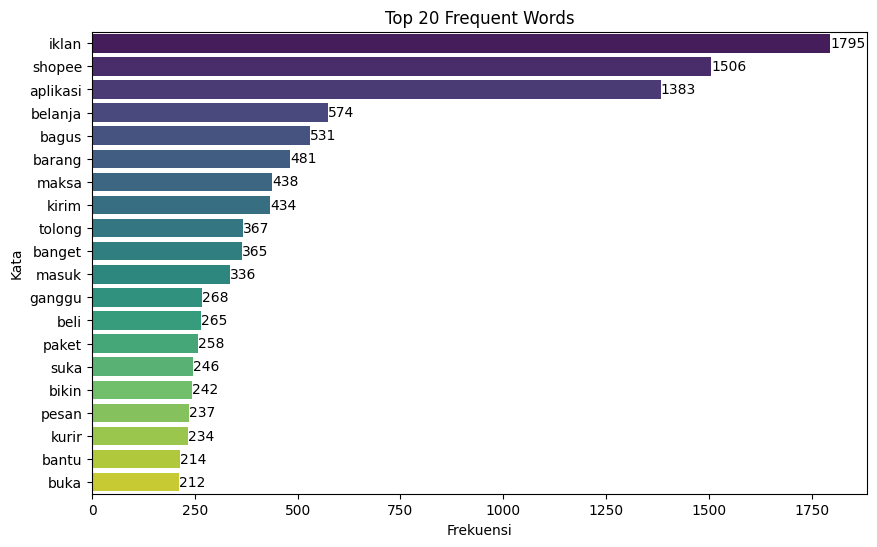

In [ ]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=top_words_df,
    x='Frekuensi',
    y='Kata',
    hue='Kata',
    palette='viridis',
    legend=False
)
for container in ax.containers:
    ax.bar_label(container)

plt.title("Top 20 Frequent Words")

plt.show()

In [ ]:
# bigram
vectorizer = CountVectorizer(
    ngram_range=(2,2),
    max_features=20
)

X = vectorizer.fit_transform(df_sentimen['stemming'])

In [ ]:
sum_words = X.sum(axis=0)

bigram = [
    (word, sum_words[0, idx])
    for word, idx in vectorizer.vocabulary_.items()
]

bigram = sorted(
    bigram,
    key=lambda x:x[1],
    reverse=True
)

bigram_df = pd.DataFrame(
    bigram,
    columns=['Bigram','Frekuensi']
)

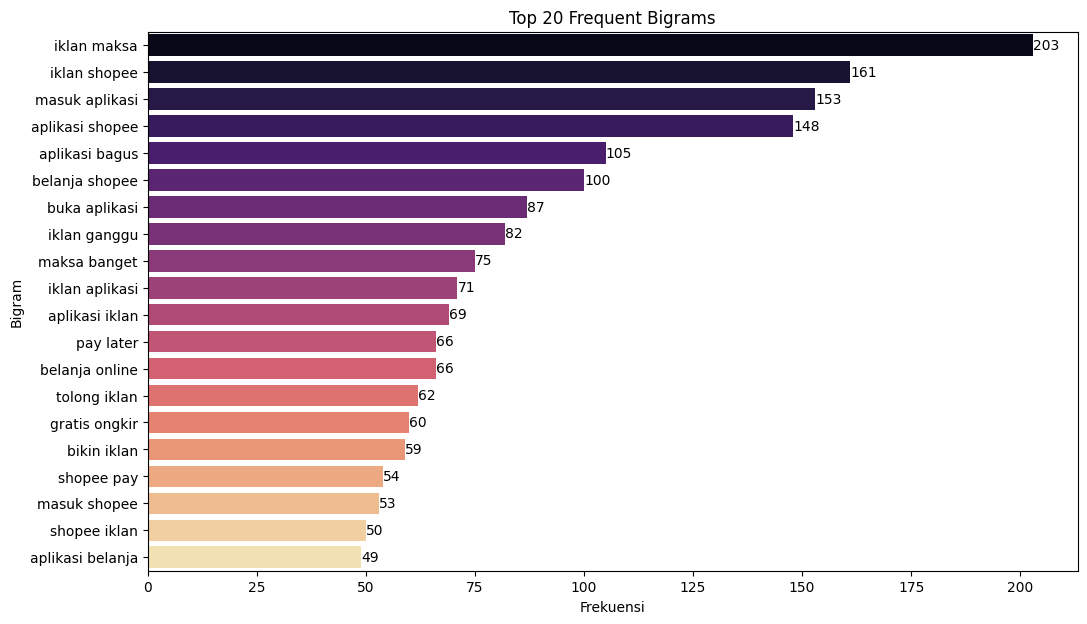

In [ ]:
plt.figure(figsize=(12,7))

ax = sns.barplot(
    data=bigram_df,
    x='Frekuensi',
    y='Bigram',
    hue='Bigram',
    palette='magma',
    legend=False
)
for container in ax.containers:
    ax.bar_label(container)

plt.title("Top 20 Frequent Bigrams")

plt.show()

# Feature Engineering

## TF-IDF

In [ ]:
df_sentimen['stemming'].head()

,stemming
0,shopee vip batas brutal benefit
1,iklan ngeselin
2,layan tingkat diskon
3,oke
4,keren


In [ ]:
# cek tipe data
df_sentimen['stemming'].apply(type).value_counts()

,count
stemming,
<class 'str'>,4148


In [ ]:
# TF-IDF
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9
)

x = tfidf.fit_transform(df_sentimen['stemming'])
y = df_sentimen['label']

In [ ]:
tfidf.get_feature_names_out()[:1000]

array(['aamiin', 'aba', 'aba aba', 'abai', 'abis', 'acara', 'acc',
       'adain', 'adain fitur', 'adain promo', 'adakan', 'adil', 'admin',
       'admin ngotak', 'admin shopee', 'adminnya', 'ads', 'adu',
       'affiliate', 'aga', 'agk', 'aja', 'ajaa', 'ajah', 'ajak', 'ajar',
       'ajg', 'aju', 'aju kembali', 'aju pinjam', 'aju shopee',
       'aju tolak', 'ak', 'akal', 'akibat', 'akses', 'aktif',
       'aktif fitur', 'aktifin', 'aktifitas', 'aktivitas',
       'aktivitas curiga', 'aktivitas muncul', 'aktivitas wajar', 'akun',
       'akun akun', 'akun batas', 'akun beli', 'akun blokir',
       'akun harga', 'akun hilang', 'akun kena', 'akun klik',
       'akun manfaat', 'akun masuk', 'akun nomor', 'akun orang',
       'akun shopee', 'akun shoppe', 'akun tolong', 'akurat', 'alam',
       'alam belanja', 'alamat', 'alamat kirim', 'alamat lengkap',
       'alamat rumah', 'alamat salah', 'alamat sesuai', 'alamat tuju',
       'alami', 'alami rugi', 'alamin', 'alan', 'alas', 'alas akti

In [ ]:
df_sentimen['stemming'].head(20)

,stemming
0,shopee vip batas brutal benefit
1,iklan ngeselin
2,layan tingkat diskon
3,oke
4,keren
5,bagus
6,kendala
7,x mes shopee pay coin paket kunjung smpai estimasi produk beli harga rendah kecewa
8,terima kasih shopee solusi beli produk
9,suka


# Modeling

## Train Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Naive Bayes

In [ ]:
# Model Naive Bayes
cnb_model = ComplementNB(alpha=0.5)
cnb_model.fit(X_train, y_train)
y_pred_cnb = cnb_model.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_cnb))
print(classification_report(y_test, y_pred_cnb, zero_division=0))

Accuracy: 0.8409638554216867
              precision    recall  f1-score   support

     negatif       0.88      0.88      0.88       442
      netral       0.34      0.26      0.29        58
     positif       0.86      0.89      0.87       330

    accuracy                           0.84       830
   macro avg       0.69      0.68      0.68       830
weighted avg       0.83      0.84      0.84       830



## Logistic Regression

In [ ]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy : 0.8614457831325302
              precision    recall  f1-score   support

     negatif       0.85      0.96      0.90       442
      netral       0.50      0.02      0.03        58
     positif       0.89      0.88      0.88       330

    accuracy                           0.86       830
   macro avg       0.74      0.62      0.61       830
weighted avg       0.84      0.86      0.83       830



## Linear SVM

In [ ]:
svm_model = LinearSVC()
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

Accuracy : 0.863855421686747
              precision    recall  f1-score   support

     negatif       0.88      0.92      0.90       442
      netral       0.38      0.14      0.20        58
     positif       0.87      0.92      0.90       330

    accuracy                           0.86       830
   macro avg       0.71      0.66      0.67       830
weighted avg       0.84      0.86      0.85       830



## Perbandingan

In [ ]:
hasil = {
    "Model": [
        "Naive Bayes",
        "Logistic Regression",
        "Linear SVM"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_cnb),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_svm)
    ],

    "Precision": [
        precision_score(y_test, y_pred_cnb, average="weighted"),
        precision_score(y_test, y_pred_lr, average="weighted"),
        precision_score(y_test, y_pred_svm, average="weighted")
    ],

    "Recall": [
        recall_score(y_test, y_pred_cnb, average="weighted"),
        recall_score(y_test, y_pred_lr, average="weighted"),
        recall_score(y_test, y_pred_svm, average="weighted")
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_cnb, average="weighted"),
        f1_score(y_test, y_pred_lr, average="weighted"),
        f1_score(y_test, y_pred_svm, average="weighted")
    ]
}

hasil = pd.DataFrame(hasil)
hasil.round(3)

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.841,0.832,0.841,0.836
1,Logistic Regression,0.861,0.838,0.861,0.832
2,Linear SVM,0.864,0.842,0.864,0.848


## Confusion Metrix

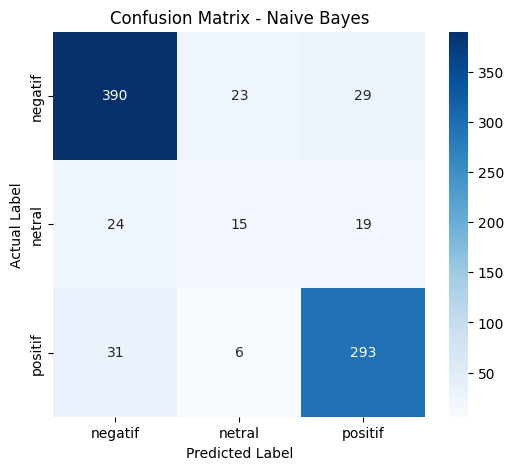

In [ ]:
cm = confusion_matrix(y_test, y_pred_cnb)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=cnb_model.classes_,
    yticklabels=cnb_model.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Naive Bayes")

plt.show()

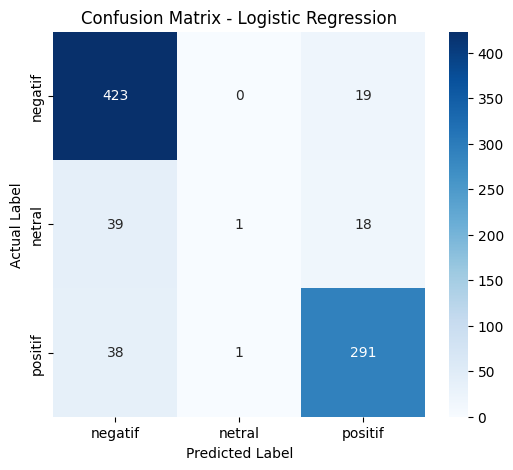

In [ ]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=lr_model.classes_,
    yticklabels=lr_model.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

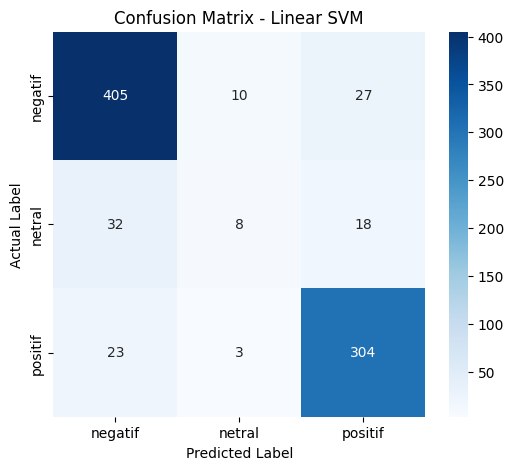

In [ ]:
cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=svm_model.classes_,
    yticklabels=svm_model.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Linear SVM")

plt.show()

# Export Model

In [ ]:
# simpan model
joblib.dump(svm_model, 'model_sentimen.joblib')
# simpan tf-idf
joblib.dump(tfidf, 'tfidf.joblib')

['tfidf.joblib']